In [21]:
import pandas as pd
import numpy as np

# 1. Carregando as duas tabelas
df = pd.read_csv('dim_clientes_202606161915.csv')
df_fato = pd.read_csv('fato_churn_202606161916.csv')

# 2. Forçando os nomes corretos com o 'I' maiúsculo (ClientId)
df_fato.columns = ['ClientId', 'DataUltimaTransacao']

# 3. Convertendo a coluna de data para o formato de data do Python
df_fato['DataUltimaTransacao'] = pd.to_datetime(df_fato['DataUltimaTransacao'])

# 4. Criando a regra de negócio do Churn (Antes de 30/09/2019 é Churn)
data_de_corte = pd.to_datetime('2019-09-30')
df_fato['Churn'] = np.where(df_fato['DataUltimaTransacao'] < data_de_corte, 1, 0)

# 5. Juntando as tabelas usando a chave correta (ClientId)
df_master = pd.merge(df, df_fato[['ClientId', 'Churn']], on='ClientId', how='left')

# Exibindo as 5 primeiras linhas para comemorar o sucesso
df_master.head()

,ClientId,DataExtracao,Score_Credito,Estado,Gênero,Idade,Tempo_Cliente,Limite_Credito_Mercado,Qte_Categorias,Usa_Cartao_Credito,Programa_Fidelidade,Sum_Pedidos_Acumulados,Churn
0,345568,2019-06-30,619,São Paulo,Feminino,42,2,0.0000,1,1,1,422.287000,1
1,345569,2019-06-30,608,Rio de Janeiro,Feminino,41,1,838.0786,1,0,1,468.927417,0
2,345570,2019-06-30,502,São Paulo,Feminino,42,8,1596.6080,3,1,0,474.714875,1
3,345571,2019-06-30,699,São Paulo,Feminino,39,1,0.0000,2,0,0,390.944292,0
4,345572,2019-06-30,850,Rio de Janeiro,Feminino,43,2,1255.1082,1,1,1,329.517083,0


In [22]:
# Calculando a correlação apenas para as colunas numéricas e focando na coluna 'Churn'
correlacao = df_master.corr(numeric_only=True)[['Churn']].sort_values(by='Churn', ascending=False)

# Exibindo o resultado
correlacao

,Churn
Churn,1.000000
Idade,0.283237
Limite_Credito_Mercado,0.116746
Sum_Pedidos_Acumulados,0.012198
Usa_Cartao_Credito,-0.006112
Tempo_Cliente,-0.013174
ClientId,-0.016589
Score_Credito,-0.028936
Qte_Categorias,-0.049865
Programa_Fidelidade,-0.154643


In [23]:
!pip install scorecardpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60629 sha256=caa2033a9883de1b9151b8e3a409f0d375398890e9d4dbbdcb263c38fd7ddc0e
  Stored in directory: /root/.cache/pip/wheels/9f/d8/4e/61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


In [24]:
import scorecardpy as sc

# Calculando o IV para todas as variáveis em relação ao 'Churn'
# Ignoramos a coluna 'Clientid' pois ela é apenas um código de identificação e não tem valor analítico
info_value = sc.iv(df_master.drop(columns=['ClientId']), y="Churn")

# Exibindo os resultados do maior para o menor poder preditivo
info_value

,variable,info_value
4,Qte_Categorias,0.931941
8,Idade,0.910873
6,Limite_Credito_Mercado,0.463426
0,Score_Credito,0.268104
10,Estado,0.166786
1,Programa_Fidelidade,0.151655
5,Gênero,0.072979
3,Tempo_Cliente,0.009086
7,Sum_Pedidos_Acumulados,0.007218
9,Usa_Cartao_Credito,0.000231


In [26]:
# Exportando para Excel (ideal para abrir no seu computador e conferir)
df_master.to_excel('resultado_churn_tocomfome.xlsx', index=False)

# Ou exportando para CSV
# df_master.to_csv('resultado_churn_tocomfome.csv', index=False)

/tmp/ipykernel_23109/3930919008.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Information_Value', y='Variavel', data=df_iv_util, palette=cores)


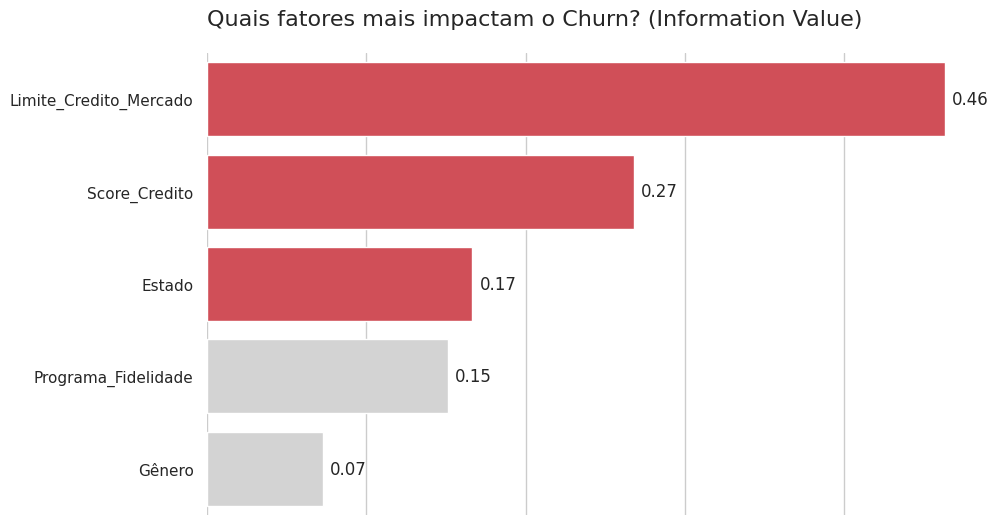

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recriando os dados exatos do cálculo de IV
dados_iv = {
    'Variavel': ['Limite_Credito_Mercado', 'Score_Credito',
                 'Estado', 'Programa_Fidelidade', 'Gênero', 'Tempo_Cliente',
                 'Sum_Pedidos_Acumulados', 'Usa_Cartao_Credito', 'DataExtracao'],
    'Information_Value': [0.4634, 0.2681, 0.1667, 0.1516,
                          0.0729, 0.0090, 0.0072, 0.0002, 0.0000]
}
df_iv = pd.DataFrame(dados_iv)

# 2. Limpeza visual: Filtrando apenas as variáveis com poder preditivo útil (IV > 0.02)
df_iv_util = df_iv[df_iv['Information_Value'] > 0.02].copy()

# 3. Configurando o estilo do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 4. Criando uma paleta de cores para reduzir a carga cognitiva (destaque apenas no Top 3)
cores = ['#e63946', '#e63946', '#e63946'] + ['#d3d3d3'] * (len(df_iv_util) - 3)

# 5. Plotando o gráfico de barras horizontais
ax = sns.barplot(x='Information_Value', y='Variavel', data=df_iv_util, palette=cores)

# 6. Adicionando os valores numéricos direto nas barras
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=5)

# 7. Refinando o design (removendo bordas e eixos desnecessários)
plt.title('Quais fatores mais impactam o Churn? (Information Value)', fontsize=16, pad=20, loc='left')
plt.xlabel('')
plt.ylabel('')
sns.despine(left=True, bottom=True)
ax.set(xticklabels=[]) # Esconde os números do eixo X inferior para o visual ficar limpo
ax.tick_params(bottom=False)

# 8. Salvando a imagem final no Colab
plt.savefig('grafico_iv_fatores_risco.png', bbox_inches='tight', dpi=300)

plt.show()

In [28]:
import pandas as pd

# 1. Criando uma coluna temporária que diz Verdadeiro (True) se a pessoa tem mais de 45 anos
df_master['Mais_de_45_anos'] = df_master['Idade'] > 45

# 2. Calculando a taxa média de Churn para cada grupo (multiplicando por 100 para virar porcentagem)
taxa_churn_idade = df_master.groupby('Mais_de_45_anos')['Churn'].mean() * 100

# 3. Exibindo o resultado
print("Taxa de Churn por Grupo de Idade:")
print(taxa_churn_idade)

Taxa de Churn por Grupo de Idade:
Mais_de_45_anos
False    13.550513
True     44.718143
Name: Churn, dtype: float64


In [29]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# 1. Separando apenas as variáveis seguras para o modelo aprender
# Removemos 'Idade' e 'Qte_Categorias' para evitar Data Leakage / Overfitting
colunas_importantes = ['Limite_Credito_Mercado', 'Score_Credito', 'Programa_Fidelidade']

# Preparando o X (o que o modelo estuda) e o y (o que o modelo prevê)
X = df_master[colunas_importantes]
y = df_master['Churn']

# 2. Criando e treinando o Algoritmo (Árvore de Decisão)
modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo.fit(X, y)

# 3. Calculando a probabilidade real de cada cliente dar Churn (0 a 100%)
df_master['Probabilidade_Churn_%'] = modelo.predict_proba(X)[:, 1] * 100

# 4. Criando as regras de Segmentação para o time de CRM
condicoes = [
    (df_master['Probabilidade_Churn_%'] >= 70),
    (df_master['Probabilidade_Churn_%'] >= 30) & (df_master['Probabilidade_Churn_%'] < 70),
    (df_master['Probabilidade_Churn_%'] < 30)
]
segmentos = ['Alto Risco', 'Médio Risco', 'Baixo Risco']

df_master['Segmento_Risco'] = np.select(condicoes, segmentos, default='Sem Classificação')

# 5. Exibindo a distribuição final e realista de risco
contagem_segmentos = df_master['Segmento_Risco'].value_counts()
print("Distribuição de Clientes por Risco (Modelo Otimizado):")
print(contagem_segmentos)

Distribuição de Clientes por Risco (Modelo Otimizado):
Segmento_Risco
Baixo Risco    6832
Médio Risco    3134
Alto Risco       34
Name: count, dtype: int64


/tmp/ipykernel_23109/3357832451.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=segmentos, y=quantidades, palette=cores)


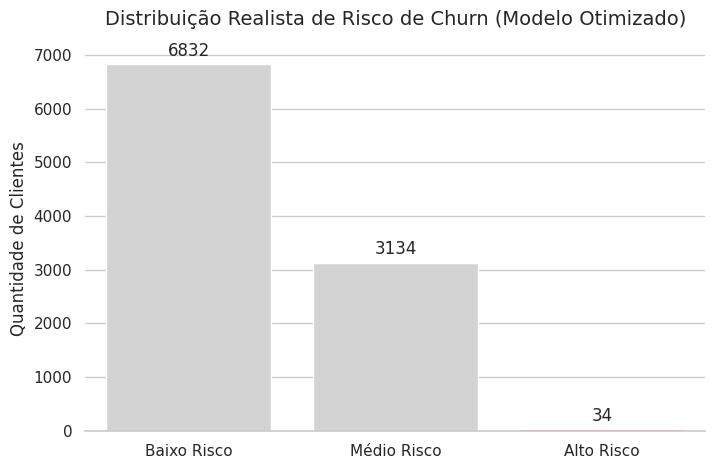

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Novos dados do modelo otimizado (sem overfitting)
segmentos = ['Baixo Risco', 'Médio Risco', 'Alto Risco']
quantidades = [6832, 3134, 34]
cores = ['#d3d3d3', '#d3d3d3', '#e63946'] # Mantendo o destaque em vermelho apenas no Alto Risco

# Criando o gráfico de barras
ax = sns.barplot(x=segmentos, y=quantidades, palette=cores)

# Adicionando os números em cima de cada barra
for i in ax.containers:
    ax.bar_label(i, padding=3)

# Ajustando títulos e removendo bordas desnecessárias
plt.title('Distribuição Realista de Risco de Churn (Modelo Otimizado)', fontsize=14, pad=15)
plt.ylabel('Quantidade de Clientes')
plt.xlabel('')
sns.despine(left=True) # Tira a linha do eixo Y para um visual mais limpo

# Salvando a imagem final no Colab
plt.savefig('grafico_distribuicao_risco_otimizado.png', bbox_inches='tight', dpi=300)

plt.show()